# Supervised Learning

## Classification

### Preparation

Untuk persiapan, kita akan memanggil seluruh library yang akan kita pakai pada project kali ini

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix
%matplotlib inline

In [4]:
train = pd.read_csv('Iris.csv')
train.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


### Exploratory Data Analysis

In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    object 
dtypes: float64(4), int64(1), object(1)
memory usage: 7.2+ KB


In [6]:
d = train.describe()
d

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


<Axes: xlabel='Species', ylabel='count'>

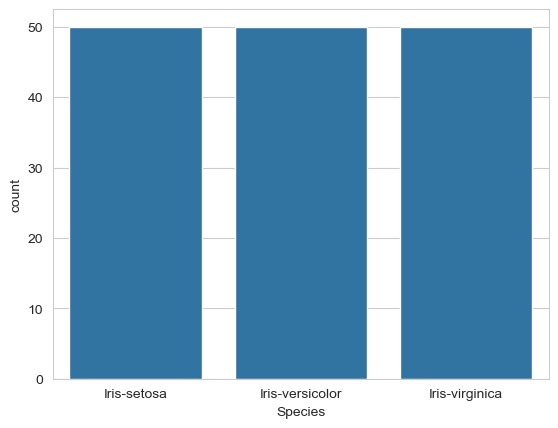

In [8]:
# Cek relative size dari species (iris setosa, versicolor, virginica)
sns.set_style('whitegrid')
sns.countplot(x='Species',data=train)

<Axes: xlabel='Species', ylabel='PetalLengthCm'>

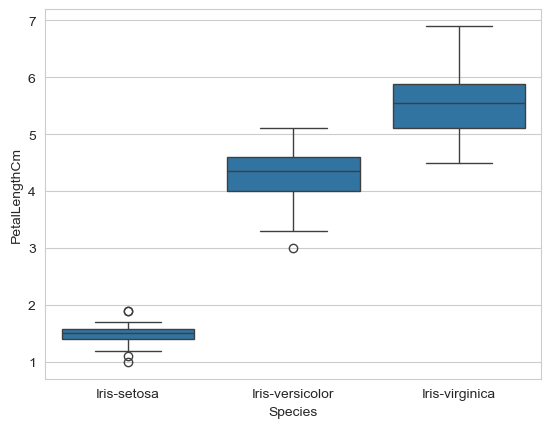

In [9]:
# Species vs petal length
sns.set_style('whitegrid')
sns.boxplot(x='Species',y='PetalLengthCm',data=train)

<Axes: xlabel='Species', ylabel='SepalLengthCm'>

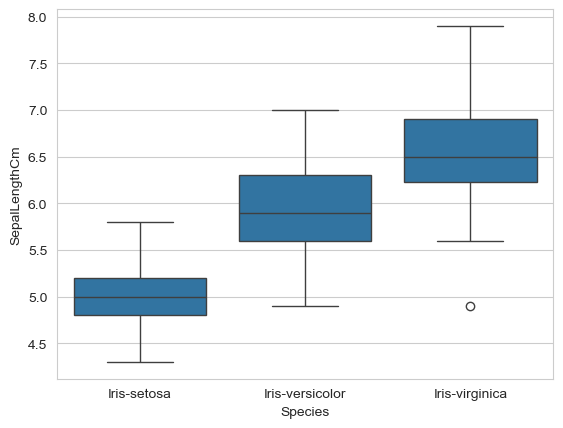

In [10]:
# Species vs sepal length
sns.set_style('whitegrid')
sns.boxplot(x='Species',y='SepalLengthCm',data=train)

Text(0.5, 0, 'Species')

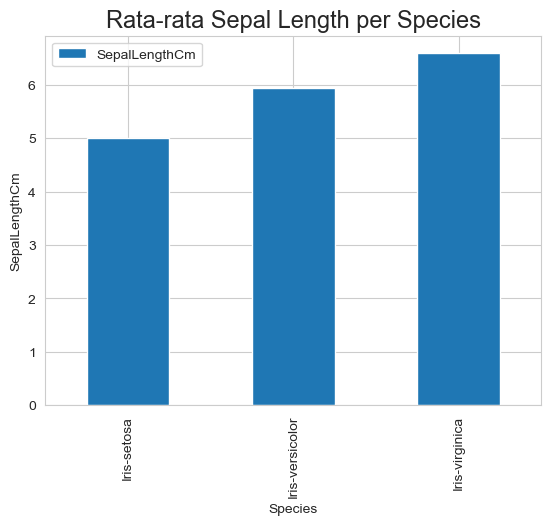

In [12]:
f_class_survived = train.groupby('Species')['SepalLengthCm'].mean()
f_class_survived = pd.DataFrame(f_class_survived)
f_class_survived.plot.bar(y='SepalLengthCm')
plt.title("Rata-rata Sepal Length per Species", fontsize=17)
plt.ylabel("SepalLengthCm")
plt.xlabel("Species")

<Axes: title={'center': 'Histogram Petal Length'}, xlabel='Petal Length (cm)', ylabel='Count'>

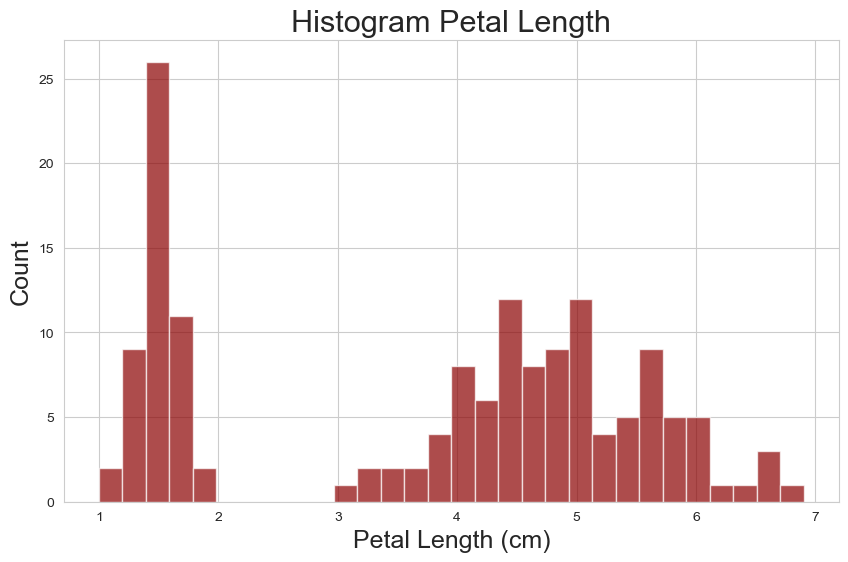

In [15]:
# Cek distribusi dari petal length
plt.xlabel("Petal Length (cm)",fontsize=18)
plt.ylabel("Count",fontsize=18)
plt.title("Histogram Petal Length",fontsize=22)
train['PetalLengthCm'].hist(bins=30,color='darkred',alpha=0.7,figsize=(10,6))

C:\Users\Dell\AppData\Local\Temp\ipykernel_20312\1369185448.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Species',y='PetalLengthCm',data=train,palette='winter')


<Axes: xlabel='Species', ylabel='Petal Length (cm)'>

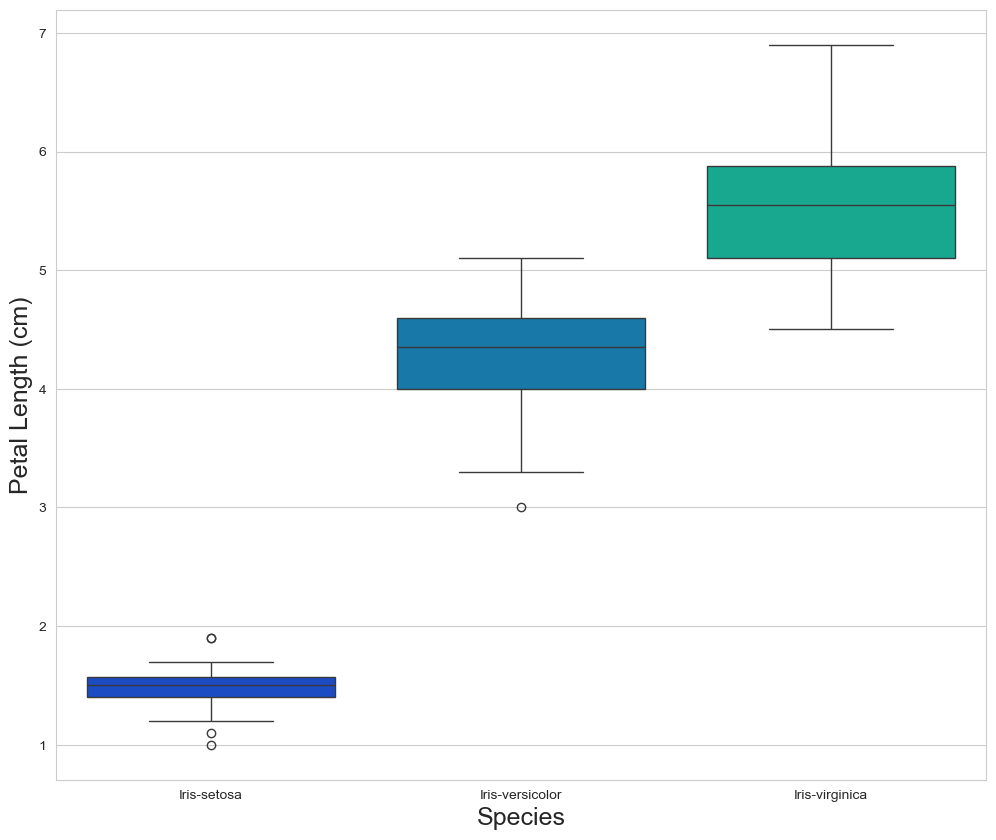

In [17]:
# Distribusi petal length di setiap kelas
plt.figure(figsize=(12, 10))
plt.xlabel("Species",fontsize=18)
plt.ylabel("Petal Length (cm)",fontsize=18)
sns.boxplot(x='Species',y='PetalLengthCm',data=train,palette='winter')

Text(0.5, 0, 'Species')

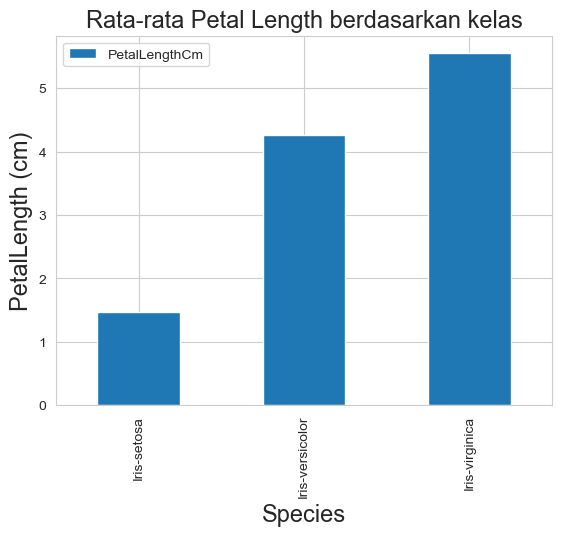

In [19]:
f_class_Age=train.groupby('Species')['PetalLengthCm'].mean()
f_class_Age = pd.DataFrame(f_class_Age)
f_class_Age.plot.bar(y='PetalLengthCm')
plt.title("Rata-rata Petal Length berdasarkan kelas",fontsize=17)
plt.ylabel("PetalLength (cm)", fontsize=17)
plt.xlabel("Species", fontsize=17)

### Fitur Engineering

In [20]:
mean_petal = train.groupby('Species')['PetalLengthCm'].mean()

def impute_petal_length(row):
    if pd.isnull(row['PetalLengthCm']):
        return mean_petal.loc[row['Species']]
    return row['PetalLengthCm']

train['PetalLengthCm'] = train.apply(impute_petal_length, axis=1)

In [21]:
mean_petal = train.groupby('Species')['PetalLengthCm'].mean()

def impute_petal_length(row):
    if pd.isnull(row['PetalLengthCm']):
        return mean_petal.loc[row['Species']]
    return row['PetalLengthCm']

train['PetalLengthCm'] = train[['PetalLengthCm', 'Species']].apply(impute_petal_length, axis=1)

Text(0.5, 1.0, 'Bar plot jumlah fitur numerik')

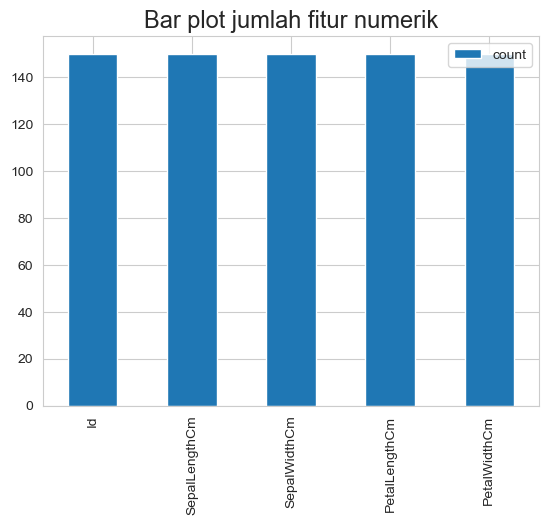

In [22]:
d=train.describe()
dT=d.T
dT.plot.bar(y='count')
plt.title("Bar plot jumlah fitur numerik",fontsize=17)

In [23]:
# Drop kolom yang tidak penting
train.drop(['Id'],axis=1,inplace=True)
train.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


### Training

In [24]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(train.drop('Species',axis=1),
                                                    train['Species'], test_size=0.30,
                                                    random_state=42)

In [25]:
print(f'Train shape: {X_train.shape}')
print(f'Test shape: {X_test.shape}')

Train shape: (105, 4)
Test shape: (45, 4)


# **KNN**

In [26]:
clf1 = KNeighborsClassifier()

clf1.fit(X_train, y_train)

KNeighborsClassifier()

In [27]:
y_pred = clf1.predict(X_test)

### Evaluation

In [28]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred) #akurasi model
print(f'Akurasi Model KNN: {accuracy:.2f}')

print("Confusion Matrix:") #confusion matrix nya
print(confusion_matrix(y_test, y_pred))

print("Classification Report:") #laporan klasifikasi
print(classification_report(y_test, y_pred))

Akurasi Model KNN: 1.00
Confusion Matrix:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]
Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        19
Iris-versicolor       1.00      1.00      1.00        13
 Iris-virginica       1.00      1.00      1.00        13

       accuracy                           1.00        45
      macro avg       1.00      1.00      1.00        45
   weighted avg       1.00      1.00      1.00        45



### jika kita mau mengubah parameter apa saja yang akan kita gunakan maka bisa dilakukan seperti ini

In [29]:
clf2 = KNeighborsClassifier(n_neighbors=5, weights='distance', metric='euclidean')
clf2.fit(X_train, y_train)

y_pred1 = clf2.predict(X_test)

In [30]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred1) #akurasi model
print(f'Akurasi Model KNN: {accuracy:.2f}')

print("Confusion Matrix:") #confusion matrix nya
print(confusion_matrix(y_test, y_pred1))

print("Classification Report:") #laporan klasifikasi
print(classification_report(y_test, y_pred1))

Akurasi Model KNN: 1.00
Confusion Matrix:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]
Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        19
Iris-versicolor       1.00      1.00      1.00        13
 Iris-virginica       1.00      1.00      1.00        13

       accuracy                           1.00        45
      macro avg       1.00      1.00      1.00        45
   weighted avg       1.00      1.00      1.00        45



### jika ingin mencoba semua parameter

In [31]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import pandas as pd

# 1. Definisikan metrik-metrik scoring yang ingin digunakan
scoring = {
    'accuracy': make_scorer(accuracy_score),
    'precision': make_scorer(precision_score, average='macro'),
    'recall': make_scorer(recall_score, average='macro'),
    'f1': make_scorer(f1_score, average='macro')
}

# 2. Parameter grid
param_grid = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# 3. Buat model KNN
knn = KNeighborsClassifier()

# 4. GridSearch dengan semua metrik, pilih 'f1' sebagai metrik utama (refit)
grid_search = GridSearchCV(knn, param_grid, cv=5, scoring=scoring, refit='f1', verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)

# 5. Hasil Cross-Validation (Training)
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_metrics = cv_results[['params', 'mean_test_accuracy', 'mean_test_precision', 'mean_test_recall', 'mean_test_f1']]
print("\n=== Hasil Evaluasi Training (Cross-Validation) ===")
print(cv_metrics.sort_values(by='mean_test_f1', ascending=False))

Fitting 5 folds for each of 12 candidates, totalling 60 fits

=== Hasil Evaluasi Training (Cross-Validation) ===
                                               params  mean_test_accuracy  \
4   {'metric': 'euclidean', 'n_neighbors': 7, 'wei...            0.952381   
5   {'metric': 'euclidean', 'n_neighbors': 7, 'wei...            0.952381   
1   {'metric': 'euclidean', 'n_neighbors': 3, 'wei...            0.942857   
2   {'metric': 'euclidean', 'n_neighbors': 5, 'wei...            0.942857   
3   {'metric': 'euclidean', 'n_neighbors': 5, 'wei...            0.942857   
6   {'metric': 'manhattan', 'n_neighbors': 3, 'wei...            0.942857   
7   {'metric': 'manhattan', 'n_neighbors': 3, 'wei...            0.942857   
8   {'metric': 'manhattan', 'n_neighbors': 5, 'wei...            0.942857   
9   {'metric': 'manhattan', 'n_neighbors': 5, 'wei...            0.942857   
10  {'metric': 'manhattan', 'n_neighbors': 7, 'wei...            0.942857   
11  {'metric': 'manhattan', 'n_neighbors

In [32]:
# Simpan hasil evaluasi ke file Excel
cv_metrics_sorted = cv_metrics.sort_values(by='mean_test_f1', ascending=False)
cv_metrics_sorted.to_excel("hasil_gridsearch_knn.xlsx", index=False)

print("Hasil telah disimpan ke 'hasil_gridsearch_knn.xlsx'")


Hasil telah disimpan ke 'hasil_gridsearch_knn.xlsx'


In [33]:
best_model = grid_search.best_estimator_
print("\n=== Parameter Terbaik ===")
print(grid_search.best_params_)


=== Parameter Terbaik ===
{'metric': 'euclidean', 'n_neighbors': 7, 'weights': 'uniform'}


In [34]:
y_pred = best_model.predict(X_test)
print("\n=== Evaluasi di Test Set ===")
print(f"Akurasi:  {accuracy_score(y_test, y_pred):.2f}")
print(f"Presisi:  {precision_score(y_test, y_pred, average='macro'):.2f}")
print(f"Recall:   {recall_score(y_test, y_pred, average='macro'):.2f}")
print(f"F1-Score: {f1_score(y_test, y_pred, average='macro'):.2f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


=== Evaluasi di Test Set ===
Akurasi:  1.00
Presisi:  1.00
Recall:   1.00
F1-Score: 1.00

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        19
Iris-versicolor       1.00      1.00      1.00        13
 Iris-virginica       1.00      1.00      1.00        13

       accuracy                           1.00        45
      macro avg       1.00      1.00      1.00        45
   weighted avg       1.00      1.00      1.00        45

Confusion Matrix:
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]


In [37]:
import numpy as np

# Data penumpang baru (dalam urutan sama seperti fitur model)
new_data = np.array([[4.8, 2.5, 3.4, 0.7]])

# Prediksi apakah penumpang ini selamat atau tidak
prediction = best_model.predict(new_data)

print("Prediksi Species:", prediction[0])

Prediksi Species: Iris-versicolor


c:\Users\Dell\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


In [38]:
from joblib import dump, load

# Simpan model
dump(best_model, 'model_knn.pkl')

['model_knn.pkl']